In [1]:
import copy
import itertools
import joblib
import warnings

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.exceptions import ConvergenceWarning

import shap

/Users/mel/venu_master/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Importation des données

In [2]:
choix = pd.read_csv("../Data/Traffic_Violations-API_20260324.csv", sep=";")
vetements = pd.read_excel("../Data/fashion_data_2018_2022.xls")

In [3]:
choix = choix.drop(columns=['Time Of Stop', 'Agency', 'SubAgency', 'Description', 'Location', 'Accident', 'Belts', 'Personal Injury', 'Property Damage', 'Fatal', 'Commercial License', 'HAZMAT', 'Alcohol', 'Work Zone', 'Violation Type', 'Charge', 'Article', 'Contributed To Accident', 'Arrest Type', 'Geolocation', 'Latitude', 'Longitude', 'Driver City', 'State', 'DL State', 'Year' ])

avant = len(choix)
temp = choix[choix["VehicleType"] == "02 - Automobile"]
temp = temp.dropna()
apres = len(temp)
perte = avant - apres
pourcentage = (perte / avant) * 100
print(f"Perte de {perte} lignes, soit {pourcentage:.2f} %")

choix = temp

# Convertir en datetime
choix['Date Of Stop'] = pd.to_datetime(choix['Date Of Stop'], format='%m/%d/%Y', errors='coerce')
choix['Year'] = choix['Date Of Stop'].dt.year

basic_colors = ['silver', 'chrome', 'gray', 'white', 'black']
choix['Color'] = choix['Color'].str.lower()
choix['Color Type'] = choix['Color'].apply(lambda x: 'basic' if x in basic_colors else 'not basic')

vetements = vetements[['product_id', 'gender', 'category', 'pattern', 'color', 'age_group', 'sales_count', 'month_of_sale', 'year_of_sale']]

Perte de 243644 lignes, soit 11.58 %


On ne garde que les informations relatives a la voiture et au conducteur.

In [4]:
Meetdeal_mark = ['Citroen', 'Hyundai', 'Seat', 'Skoda', 'Volkswagen', 'CUPRA', 'OPEL', 'Dacia', 'Renault', 'DS', 'VWU',       'AUDI', 'Fiat', 'Peugeot', 'KIA', 'AlfaRomeo', 'Honda', 'Lancia', 'Toyota']

Meetdeal_mark = [x.upper() for x in Meetdeal_mark]

In [5]:
import re
import pandas as pd

# Liste en majuscules + homogénéisée
Meetdeal_mark = [
    'CITROEN','HYUNDAI','SEAT','SKODA','VOLKSWAGEN',
    'CUPRA','OPEL','DACIA','RENAULT','DS',
    'VWU','AUDI','FIAT','PEUGEOT','KIA',
    'ALFAROMEO','HONDA','LANCIA','TOYOTA'
]

def normalize_make(x):
    if pd.isna(x):
        return x
    
    x = x.upper().strip()
    x = re.sub(r'[^A-Z0-9 ]', '', x)

    # Mapping uniquement vers tes marques
    patterns = {
        r'.*\bTOY.*': 'TOYOTA',
        r'.*\bHON.*': 'HONDA',
        r'.*\bHYUN.*|.*\bHYN.*': 'HYUNDAI',
        r'.*\bKIA.*': 'KIA',
        r'.*\bVOLK.*|.*\bVW.*': 'VOLKSWAGEN',
        r'.*\bAUD.*': 'AUDI',
        r'.*\bFIAT.*': 'FIAT',
        r'.*\bPEUG.*': 'PEUGEOT',
        r'.*\bCITR.*': 'CITROEN',
        r'.*\bREN.*': 'RENAULT',
        r'.*\bDAC.*': 'DACIA',
        r'.*\bOPEL.*': 'OPEL',
        r'.*\bSEAT.*': 'SEAT',
        r'.*\bSKO.*': 'SKODA',
        r'.*\bCUPRA.*': 'CUPRA',
        r'.*\bDS.*': 'DS',
        r'.*\bALFA.*': 'ALFAROMEO',
        r'.*\bLANC.*': 'LANCIA'
    }

    for pattern, brand in patterns.items():
        if re.match(pattern, x):
            return brand
    
    return None  # 👈 important : on rejette tout le reste

before = len(choix)
choix["Make"] = choix["Make"].apply(normalize_make)
choix = choix[choix["Make"].isin(Meetdeal_mark)]
after = len(choix)

perte = before - after
pourcentage = perte / before

print(f"Perte de {perte} lignes, soit {pourcentage:.2f} %")

Perte de 1042050 lignes, soit 0.56 %


In [6]:
print(list(choix["Make"].unique()))

['HONDA', 'TOYOTA', 'VOLKSWAGEN', 'HYUNDAI', 'AUDI', 'KIA', 'ALFAROMEO', 'FIAT', 'PEUGEOT']


In [7]:
Meetdeal_modele = ['C3 aircross', 'C3', 'Ami', 'Tucson', 'Arona', 'Kamiq', 'Taigo', 'Leon', 'C4', 'C5 aircross', 'Vivaro', 'Mokka','Corsa', 'C5 x', 'Kona', 'C4 x', 'Polo', 'Astra', 'Grandland', 'Captur', 'Up!', 'E-up!', 'Crossland', 'Combo', 'Ds 4', 'Ds 7', 'Movano', 'T-roc', 'Id.3', 'Bigster', 'Ibiza', 'I10', 'Bayon', 'Tiguan', 'Octavia', 'Transporter', 'Fabia', 'Karoq', 'Golf', 'T-cross', 'A3', 'Elroq', '600', '208', 'Frontera', 'Niro', 'Stonic', 'Ceed', 'Inster', 'Sportage', 'Picanto', 'Tonale', 'Jazz', 'Q4 e-tron', 'Ateca', 'Id.4', 'Formentor', 'Tayron', 'Born', 'Ev3', '600e', 'Junior', 'Topolino', 'Ds 3', '500e', 'Hr-v', 'Ev6', '408', 'Ypsilon', 'Kodiaq', 'Q5', 'Q2', 'A1', 'I20', 'Terramar', 'Tavascan', 'Q3', 'Enyaq', 'Yaris', 'A6']

Meetdeal_modele = [x.upper() for x in Meetdeal_modele]

In [8]:
def normalize_model(x):
    if pd.isna(x):
        return x

    x = str(x).upper().strip()
    x = re.sub(r'[^A-Z0-9 ]', '', x)

    # Mapping des motifs vers les modèles standardisés
    patterns = {
        # Modèles Citroën
        r'.*\bC3.*AIRCROSS.*': 'C3 AIRCROSS',
        r'.*\bC3\b.*': 'C3',
        r'.*\bC4.*AIRCROSS.*': 'C4 AIRCROSS',
        r'.*\bC4.*X.*': 'C4 X',
        r'.*\bC4\b.*': 'C4',
        r'.*\bC5.*AIRCROSS.*': 'C5 AIRCROSS',
        r'.*\bC5.*X.*': 'C5 X',
        # Modèles Hyundai
        r'.*\bTUCSON.*': 'TUCSON',
        r'.*\bKONA.*': 'KONA',
        r'.*\bI10.*': 'I10',
        r'.*\bI20.*': 'I20',
        # Modèles Seat
        r'.*\bARONA.*': 'ARONA',
        r'.*\bLEON.*': 'LEON',
        r'.*\bIBIZA.*': 'IBIZA',
        # Modèles Skoda
        r'.*\bKAMIQ.*': 'KAMIQ',
        r'.*\bOCTAVIA.*': 'OCTAVIA',
        r'.*\bKAROQ.*': 'KAROQ',
        # Modèles Volkswagen
        r'.*\bPOLO.*': 'POLO',
        r'.*\bGOLF.*': 'GOLF',
        r'.*\bT\-?ROC.*': 'T-ROC',
        r'.*\bID\.?3.*': 'ID.3',
        r'.*\bID\.?4.*': 'ID.4',
        r'.*\bUP.*': 'UP!',
        r'.*\bE\-?UP.*': 'E-UP!',
        # Modèles Opel
        r'.*\bCORSA.*': 'CORSA',
        r'.*\bASTRA.*': 'ASTRA',
        r'.*\bGRANDLAND.*': 'GRANDLAND',
        r'.*\bCROSSLAND.*': 'CROSSLAND',
        r'.*\bCOMBO.*': 'COMBO',
        r'.*\bVIVARO.*': 'VIVARO',
        r'.*\bMOVANO.*': 'MOVANO',
        # Modèles Dacia
        r'.*\bDS\b.*3.*': 'DS 3',
        r'.*\bDS\b.*4.*': 'DS 4',
        r'.*\bDS\b.*7.*': 'DS 7',
        # Modèles Renault
        r'.*\bCAPTUR.*': 'CAPTUR',
        # Modèles Toyota
        r'.*\bYARIS.*': 'YARIS',
        r'.*\bCOROLLA.*': 'COROLLA',  # À adapter selon ta liste
        # Modèles Kia
        r'.*\bNIRO.*': 'NIRO',
        r'.*\bSTONIC.*': 'STONIC',
        r'.*\bCEED.*': 'CEED',
        r'.*\bSPORTAGE.*': 'SPORTAGE',
        r'.*\bPICANTO.*': 'PICANTO',
        # Modèles Honda
        r'.*\bJAZZ.*': 'JAZZ',
        r'.*\bHR\-?V.*': 'HR-V',
        # Modèles Audi
        r'.*\bA3.*': 'A3',
        r'.*\bA6.*': 'A6',
        r'.*\bQ2.*': 'Q2',
        r'.*\bQ3.*': 'Q3',
        r'.*\bQ5.*': 'Q5',
        r'.*\bQ4.*E\-?TRON.*': 'Q4 E-TRON',
        # Modèles Peugeot
        r'.*\b208.*': '208',
        r'.*\b408.*': '408',
        # Modèles Fiat
        r'.*\b500.*E.*': '500E',
        r'.*\bYPSILON.*': 'YPSILON',
        # Modèles Cupra
        r'.*\bATECA.*': 'ATECA',
        r'.*\bFORMENTOR.*': 'FORMENTOR',
        # Modèles Alfa Romeo
        r'.*\bTONALE.*': 'TONALE',
        # Modèles Lancia
        r'.*\bYPSILON.*': 'YPSILON',
        # Modèles DS
        r'.*\bDS\b.*3.*': 'DS 3',
        r'.*\bDS\b.*4.*': 'DS 4',
        r'.*\bDS\b.*7.*': 'DS 7',
        # Modèles divers
        r'.*\bTERRAMAR.*': 'TERRAMAR',
        r'.*\bTAVASCAN.*': 'TAVASCAN',
        r'.*\bENYAQ.*': 'ENYAQ',
        r'.*\bEV6.*': 'EV6',
        r'.*\bEV3.*': 'EV3',
        r'.*\b600E.*': '600E',
        r'.*\bJUNIOR.*': 'JUNIOR',
        r'.*\bTOPOLINO.*': 'TOPOLINO',
    }

    for pattern, model in patterns.items():
        if re.match(pattern, x):
            return model

    return None

# Application
before = len(choix)
choix["Model"] = choix["Model"].apply(normalize_model)
choix = choix[choix["Model"].isin(Meetdeal_modele)]
after = len(choix)

perte = before - after
pourcentage = perte / before

print(f"Perte de {perte} lignes, soit {pourcentage:.2%} du dataset initial.")

Perte de 802223 lignes, soit 98.07% du dataset initial.


In [9]:
print(list(choix["Model"].unique()))

['HR-V', 'Q5', 'YARIS', 'A3', 'ID.4', 'SPORTAGE', 'TUCSON', 'GOLF', 'NIRO', 'KONA', 'Q3', 'A6', 'EV6', 'POLO', 'Q4 E-TRON', 'Q2', 'UP!']


In [10]:
choix.head()

,Date Of Stop,Commercial Vehicle,VehicleType,Make,Model,Color,Race,Gender,Driver State,Year,Color Type
45,2026-03-23,No,02 - Automobile,HONDA,HR-V,gray,BLACK,M,MD,2026,basic
88,2026-03-22,No,02 - Automobile,AUDI,Q5,"blue, light",BLACK,F,MD,2026,not basic
89,2026-03-22,No,02 - Automobile,AUDI,Q5,"blue, light",BLACK,F,MD,2026,not basic
543,2026-03-21,No,02 - Automobile,TOYOTA,YARIS,silver,HISPANIC,F,MD,2026,basic
551,2026-03-21,No,02 - Automobile,AUDI,A3,black,BLACK,F,MD,2026,basic


In [11]:
vetements.head()

,product_id,gender,category,pattern,color,age_group,sales_count,month_of_sale,year_of_sale
0,1001,Male,Shirt,Geometric,White,25-35,75,1,2018
1,1002,Male,Jacket,Polka Dots,Beige,18-24,296,1,2018
2,1003,Female,Dress,Geometric,Brown,18-24,50,1,2018
3,1004,Male,Shorts,Plain,White,25-35,435,1,2018
4,1005,Male,Shirt,Plain,Beige,35-45,79,1,2018


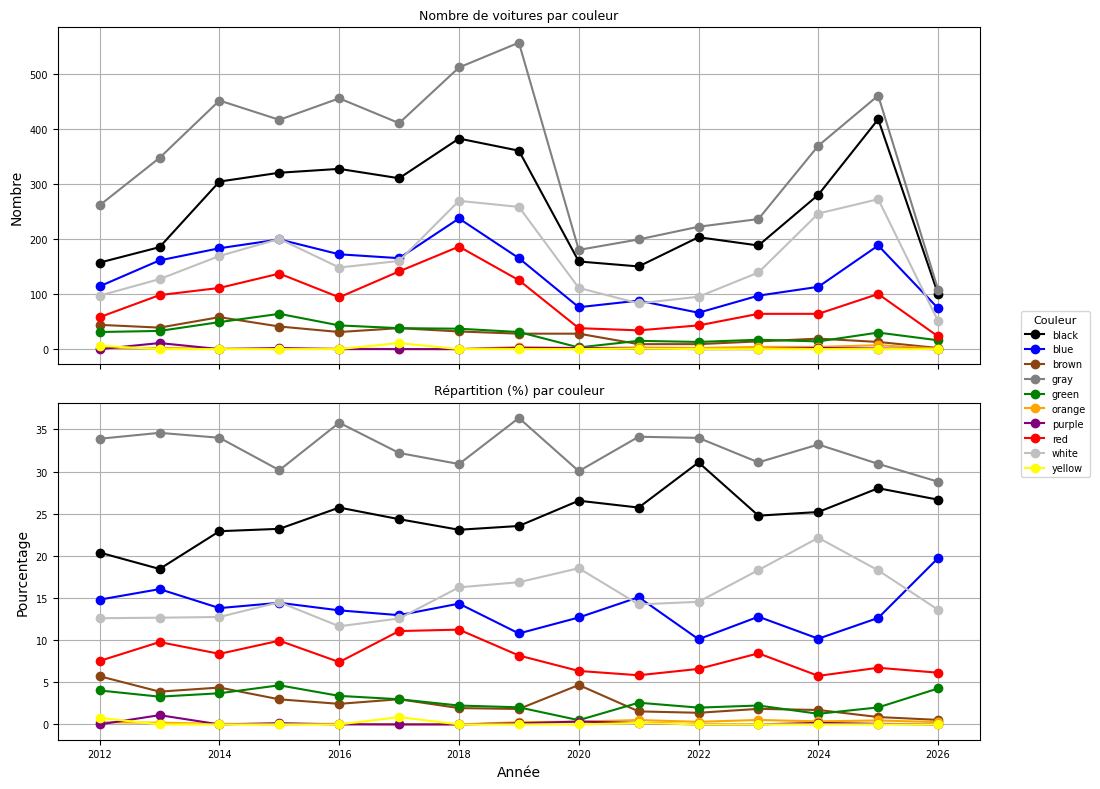

In [12]:
# -----------------------------
# Préparation des données
# -----------------------------

color_map = {
    'blue': ['blue', 'blue, light', 'blue, dark'],
    'green': ['green', 'green, lgt', 'green, dk'],
    'red': ['red', 'maroon'],
    'brown': ['brown', 'tan', 'cream', 'gold', 'bronze', 'copper', 'beige'],
    'white': ['white'],
    'black': ['black'],
    'orange': ['orange'],
    'yellow': ['yellow'],
    'pink': ['pink'],
    'purple': ['purple'],
    'multicolor': ['multicolor', 'camouflage'],
    'gray': ['silver', 'chrome', 'gray']
}

def general_color(c):
    for gen, shades in color_map.items():
        if c in shades:
            return gen
    return 'other'

choix['Color_general'] = choix['Color'].apply(general_color)

counts = choix.groupby(['Year', 'Color_general']).size().unstack(fill_value=0)
counts_percent = counts.div(counts.sum(axis=1), axis=0) * 100

palette = {
    'blue': 'blue',
    'green': 'green',
    'red': 'red',
    'brown': 'saddlebrown',
    'white': 'silver',
    'black': 'black',
    'orange': 'orange',
    'yellow': 'yellow',
    'pink': 'pink',
    'purple': 'purple',
    'multicolor': 'magenta',
    'gray': 'gray',
    'other': 'cyan'
}

# -----------------------------
# Subplots
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

lines = []
labels = []

# ---- Graphique 1 ----
for color in counts.columns:
    line, = axes[0].plot(
        counts.index,
        counts[color],
        marker='o',
        color=palette.get(color, 'gray'),
        label=color
    )
    lines.append(line)
    labels.append(color)

axes[0].set_title("Nombre de voitures par couleur")
axes[0].set_ylabel("Nombre")
axes[0].grid(True)

# ---- Graphique 2 ----
for color in counts_percent.columns:
    axes[1].plot(
        counts_percent.index,
        counts_percent[color],
        marker='o',
        color=palette.get(color, 'gray')
    )

axes[1].set_title("Répartition (%) par couleur")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Pourcentage")
axes[1].grid(True)

# -----------------------------
# Légende unique
# -----------------------------
fig.legend(
    lines, labels,
    title="Couleur",
    loc='center right',
    bbox_to_anchor=(1.1, 0.5),
    fontsize=7,
    title_fontsize=8
)

# Ajustements taille texte
for ax in axes:
    ax.tick_params(labelsize=7)
    ax.title.set_size(9)

plt.tight_layout()
plt.show()

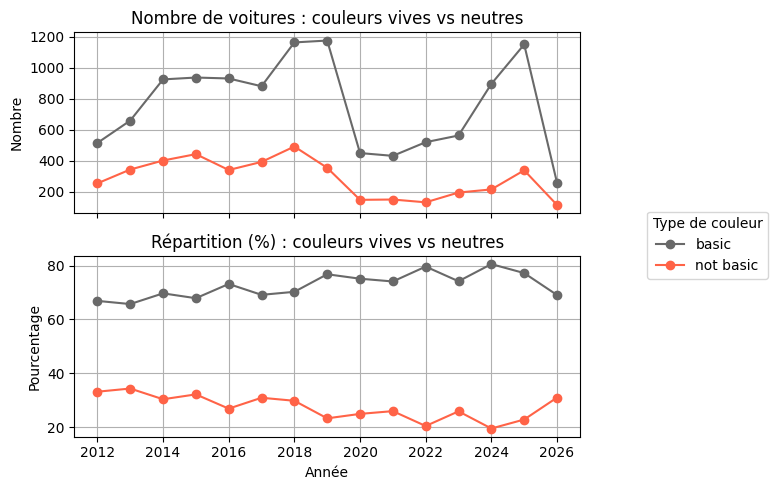

In [13]:
# -----------------------------
# 2️⃣ Agrégation
# -----------------------------
counts = choix.groupby(['Year', 'Color Type']).size().unstack(fill_value=0)
counts_percent = counts.div(counts.sum(axis=1), axis=0) * 100

# -----------------------------
# 3️⃣ Palette
# -----------------------------
palette = {
    'not basic': 'tomato',
    'basic': 'dimgray',
    'other': 'cyan'
}

# -----------------------------
# 4️⃣ Subplots
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

lines = []
labels = []

# ---- Graphique 1 ----
for t in counts.columns:
    line, = axes[0].plot(
        counts.index,
        counts[t],
        marker='o',
        color=palette.get(t, 'black'),
        label=t
    )
    lines.append(line)
    labels.append(t)

axes[0].set_title("Nombre de voitures : couleurs vives vs neutres")
axes[0].set_ylabel("Nombre")
axes[0].grid(True)

# ---- Graphique 2 ----
for t in counts_percent.columns:
    axes[1].plot(
        counts_percent.index,
        counts_percent[t],
        marker='o',
        color=palette.get(t, 'black')
    )

axes[1].set_title("Répartition (%) : couleurs vives vs neutres")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Pourcentage")
axes[1].grid(True)

# -----------------------------
# 5️⃣ Légende unique
# -----------------------------
fig.legend(lines, labels, title="Type de couleur",
           loc='center right', bbox_to_anchor=(1.3, 0.5))

plt.tight_layout()
plt.show()

La baisse des accidents de la route aux États-Unis en 2020 est principalement due à la pandémie de COVID-19, qui a fortement réduit les déplacements (confinements, télétravail). Moins de voitures sur les routes = moins d’accidents.

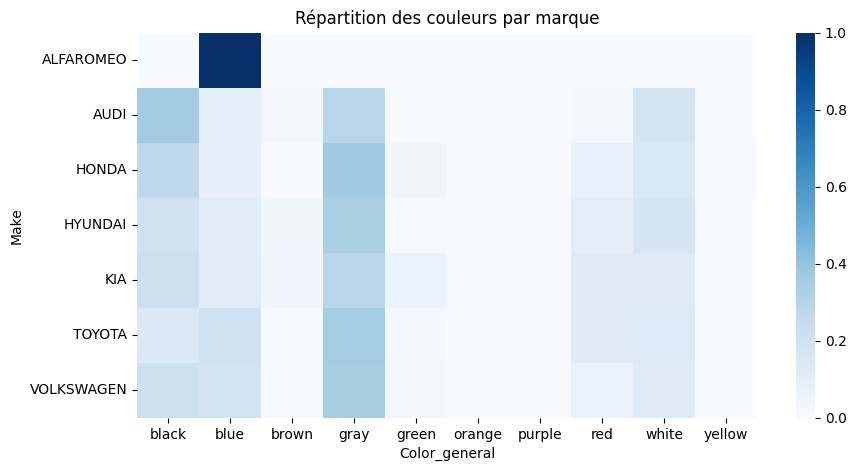

In [14]:
table = pd.crosstab(choix["Make"], choix["Color_general"], normalize="index")

plt.figure(figsize=(10,5))
sns.heatmap(table, cmap="Blues")
plt.title("Répartition des couleurs par marque")
plt.show()

# Prédiction 

In [15]:
variables = ["Make", "Model", "VehicleType", "Driver State", "Gender", "Race"]

for var in variables:
    table = pd.crosstab(choix[var], choix["Color_general"])
    _, p, _, _ = chi2_contingency(table)
    print(f"{var} → p-value = {p:.2f}")

Make → p-value = 0.00
Model → p-value = 0.00
VehicleType → p-value = 1.00
Driver State → p-value = 0.00
Gender → p-value = 0.00
Race → p-value = 0.00


## Info interne

### Couleur précise

#### Random Forest

Le modèle peut produire des prédictions pour des années futures (ex : 2030), mais celles-ci reposent sur l’hypothèse que les tendances observées dans les données historiques restent stables dans le temps.

In [16]:
# Features (X) et target (y)
X = choix[["Commercial Vehicle", "Year", "Make", "Model", "Race", "Gender", "Driver State"]]
y = choix["Color_general"]

In [17]:
categorical_cols = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [18]:
model_precis = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier())
])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
model_precis.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
y_pred = model_precis.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.4215530903328051
F1-score : 0.40759639232276335


In [22]:
# Récupérer le modèle entraîné
rf = model_precis.named_steps["classifier"]

# Récupérer les noms des variables après OneHotEncoder
feature_names = model_precis.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(X.columns)

# Importance des variables
importances = rf.feature_importances_

# DataFrame lisible
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(20))

            feature  importance
65  Driver State_MD    0.051088
44       Race_WHITE    0.049811
40       Race_BLACK    0.043377
45         Gender_F    0.041639
46         Gender_M    0.040450
41    Race_HISPANIC    0.040180
43       Race_OTHER    0.038750
7         Year_2018    0.035160
14        Year_2025    0.033504
39       Race_ASIAN    0.032320
8         Year_2019    0.031526
6         Year_2017    0.030365
12        Year_2023    0.029499
53  Driver State_DC    0.029255
13        Year_2024    0.028728
5         Year_2016    0.028062
86  Driver State_VA    0.027153
4         Year_2015    0.026534
11        Year_2022    0.026053
3         Year_2014    0.025933


### Autres

In [23]:

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [24]:
# -----------------------------
# 1. FEATURES / TARGET
# -----------------------------
features = ["Year", "Make", "Model", "Driver State"]
target = "Color_general"

# Tri temporel
choix = choix.sort_values("Year")

# Split temporel
train = choix[choix["Year"] < 2025]
test = choix[choix["Year"] >= 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# -----------------------------
# 🔥 ENCODAGE TARGET (IMPORTANT)
# -----------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# -----------------------------
# 2. PREPROCESSING
# -----------------------------
categorical_cols = ["Make", "Model", "Driver State"]
numeric_cols = ["Year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# -----------------------------
# 3. MODELS
# -----------------------------

models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    
    "GradientBoosting": GradientBoostingClassifier(),
    
    "LogisticRegression": LogisticRegression(max_iter=1000),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric="mlogloss"
    )
}

# -----------------------------
# 4. TRAIN + EVALUATE
# -----------------------------
print("=== Modèles avec OneHotEncoder ===")

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    
    # ⚠️ utiliser y encodé
    pipe.fit(X_train, y_train_enc)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test_enc, y_pred)
    f1 = f1_score(y_test_enc, y_pred, average="weighted")
    
    print(f"{name} : Accuracy={acc:.4f} | F1={f1:.4f}")

# -----------------------------
# 5. CATBOOST (sans OneHot)
# -----------------------------
print("\n=== CatBoost (catégories natives) ===")

cat_features = ["Make", "Model", "Driver State"]

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

# CatBoost accepte y texte directement
cat_model.fit(X_train, y_train, cat_features=cat_features)

y_pred_cat = cat_model.predict(X_test)

# ⚠️ flatten car CatBoost retourne parfois un array 2D
y_pred_cat = y_pred_cat.flatten()

acc_cat = accuracy_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat, average="weighted")

print(f"CatBoost : Accuracy={acc_cat:.4f} | F1={f1_cat:.4f}")

=== Modèles avec OneHotEncoder ===
RandomForest : Accuracy=0.3113 | F1=0.2536
GradientBoosting : Accuracy=0.3194 | F1=0.2480
LogisticRegression : Accuracy=0.3290 | F1=0.2270
XGBoost : Accuracy=0.3119 | F1=0.2310

=== CatBoost (catégories natives) ===
CatBoost : Accuracy=0.3113 | F1=0.2336


### Type de couleur

#### Random Forest

In [25]:
# Features (X) et target (y)
X = choix[["Commercial Vehicle", "Year", "Make", "Model", "Race", "Gender", "Driver State"
]]
y = choix["Color Type"]

In [26]:
categorical_cols = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [27]:
model_general = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
model_general.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
y_pred = model_general.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.7613312202852615
F1-score : 0.7354003130320441


#### Autres

In [31]:
# -----------------------------
# 1. FEATURES / TARGET
# -----------------------------
features = ["Year", "Make", "Model", "Driver State", "Race", "Gender"]
target = "Color Type"

# Tri temporel
choix = choix.sort_values("Year")

# Split temporel
train = choix[choix["Year"] < 2025]
test = choix[choix["Year"] >= 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# -----------------------------
# 🔥 ENCODAGE TARGET (IMPORTANT)
# -----------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# -----------------------------
# 2. PREPROCESSING
# -----------------------------
categorical_cols = ["Make", "Model", "Driver State", "Race", "Gender"]
numeric_cols = ["Year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# -----------------------------
# 3. MODELS
# -----------------------------
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    
    "GradientBoosting": GradientBoostingClassifier(),
    
    "LogisticRegression": LogisticRegression(max_iter=1000),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric="mlogloss"
    )
}

# -----------------------------
# 4. TRAIN + EVALUATE
# -----------------------------
print("=== Modèles avec OneHotEncoder ===")

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    
    # ⚠️ utiliser y encodé
    pipe.fit(X_train, y_train_enc)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test_enc, y_pred)
    f1 = f1_score(y_test_enc, y_pred, average="weighted")
    
    print(f"{name} : Accuracy={acc:.4f} | F1={f1:.4f}")

# -----------------------------
# 5. CATBOOST (sans OneHot)
# -----------------------------
print("\n=== CatBoost (catégories natives) ===")

cat_features = ["Make", "Model", "Driver State", "Race", "Gender"]

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

# CatBoost accepte y texte directement
cat_model.fit(X_train, y_train, cat_features=cat_features)

y_pred_cat = cat_model.predict(X_test)

# ⚠️ flatten car CatBoost retourne parfois un array 2D
y_pred_cat = y_pred_cat.flatten()

acc_cat = accuracy_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat, average="weighted")

print(f"CatBoost : Accuracy={acc_cat:.4f} | F1={f1_cat:.4f}")

=== Modèles avec OneHotEncoder ===
RandomForest : Accuracy=0.7262 | F1=0.6614
GradientBoosting : Accuracy=0.7552 | F1=0.6504
LogisticRegression : Accuracy=0.7552 | F1=0.6524
XGBoost : Accuracy=0.7397 | F1=0.6508

=== CatBoost (catégories natives) ===
CatBoost : Accuracy=0.7477 | F1=0.6467


In [32]:
# -----------------------------
# 1. FEATURES / TARGET
# -----------------------------
features = ["Year", "Make", "Model", "Driver State", "Gender"]
target = "Color Type"

# Tri temporel
choix = choix.sort_values("Year")

# Split temporel
train = choix[choix["Year"] < 2025]
test = choix[choix["Year"] >= 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# -----------------------------
# 🔥 ENCODAGE TARGET
# -----------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# -----------------------------
# 2. PREPROCESSING
# -----------------------------
categorical_cols = ["Make", "Model", "Driver State", "Gender"]
numeric_cols = ["Year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# -----------------------------
# 3. MODELS
# -----------------------------
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric="mlogloss"
    )
}

# -----------------------------
# 4. TRAIN + EVALUATE
# -----------------------------
results = []

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    
    # entraînement
    pipe.fit(X_train, y_train_enc)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test_enc, y_pred)
    f1 = f1_score(y_test_enc, y_pred, average="weighted")
    
    print(f"{name} : Accuracy={acc:.4f} | F1={f1:.4f}")
    
    # stocker résultats
    results.append({
        "name": name,
        "model": pipe,
        "accuracy": acc,
        "f1": f1
    })

# -----------------------------
# 5. CATBOOST (sans OneHot)
# -----------------------------
cat_features = ["Make", "Model", "Driver State", "Gender"]

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

cat_model.fit(X_train, y_train, cat_features=cat_features)
y_pred_cat = cat_model.predict(X_test).flatten()

acc_cat = accuracy_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat, average="weighted")

print(f"CatBoost : Accuracy={acc_cat:.4f} | F1={f1_cat:.4f}")

# Ajouter CatBoost aux résultats
results.append({
    "name": "CatBoost",
    "model": cat_model,
    "accuracy": acc_cat,
    "f1": f1_cat
})

# -----------------------------
# 6. SÉLECTION DU MEILLEUR MODÈLE
# -----------------------------
# Trier par accuracy (desc) puis F1 (desc)
results_sorted = sorted(results, key=lambda x: (x["accuracy"], x["f1"]), reverse=True)

best_model_info = results_sorted[0]
best_model_name = best_model_info["name"]
best_model = best_model_info["model"]
best_accuracy = best_model_info["accuracy"]
best_f1 = best_model_info["f1"]

print(f"\n=== Meilleur modèle ===")
print(f"{best_model_name} | Accuracy={best_accuracy:.4f} | F1={best_f1:.4f}")

# Maintenant `best_model` peut être utilisé pour prédiction, SHAP, etc.

RandomForest : Accuracy=0.7461 | F1=0.6497
GradientBoosting : Accuracy=0.7558 | F1=0.6506
LogisticRegression : Accuracy=0.7552 | F1=0.6524
XGBoost : Accuracy=0.7472 | F1=0.6474
CatBoost : Accuracy=0.7558 | F1=0.6506

=== Meilleur modèle ===
GradientBoosting | Accuracy=0.7558 | F1=0.6506


In [35]:
# -----------------------------
# 1. Transformer X_test
# -----------------------------
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)

# Si sparse, convertir en dense
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Convertir en DataFrame avec noms des features
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Forcer toutes les colonnes en float
X_test_df = X_test_df.apply(pd.to_numeric, errors='coerce')

# -----------------------------
# 2. Créer l’explainer SHAP selon le type de modèle
# -----------------------------
if best_model_name == "LogisticRegression":
    explainer = shap.LinearExplainer(
        best_model.named_steps["model"],
        X_test_df,
        feature_perturbation="interventional"
    )
    shap_values = explainer.shap_values(X_test_df)

elif best_model_name in ["RandomForest", "GradientBoosting", "XGBoost"]:
    explainer = shap.TreeExplainer(best_model.named_steps["model"])
    shap_values = explainer.shap_values(X_test_df)

elif best_model_name == "CatBoost":
    # CatBoost accepte le DataFrame original avec cat_features
    pool = best_model.Pool(X_test, cat_features=cat_features)
    shap_values = best_model.get_feature_importance(data=pool, type="ShapValues")
    shap_values = shap_values[:, :-1]  # retirer base_value

# -----------------------------
# 3. Calculer l’importance globale
# -----------------------------
if isinstance(shap_values, list):  # multiclass
    shap_importance = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    shap_importance = np.abs(shap_values).mean(axis=0)

# DataFrame interprétable
shap_df = pd.DataFrame({
    "feature": X_test_df.columns if best_model_name != "CatBoost" else features,
    "importance": shap_importance
}).sort_values("importance", ascending=False)

# -----------------------------
# 4. Afficher top 20 features
# -----------------------------
print(shap_df.head(20))

                 feature  importance
67             num__Year    0.363800
0         cat__Make_AUDI    0.262717
1        cat__Make_HONDA    0.125548
10       cat__Model_HR-V    0.073687
4       cat__Make_TOYOTA    0.045628
12       cat__Model_KONA    0.034731
20      cat__Model_YARIS    0.022791
3          cat__Make_KIA    0.018985
11       cat__Model_ID.4    0.013818
6          cat__Model_A3    0.012508
16         cat__Model_Q5    0.012416
26  cat__Driver State_DC    0.009661
15         cat__Model_Q3    0.009051
64         cat__Gender_F    0.007842
66         cat__Gender_U    0.007570
13       cat__Model_NIRO    0.007097
65         cat__Gender_M    0.006775
5   cat__Make_VOLKSWAGEN    0.005256
29  cat__Driver State_GA    0.004616
18     cat__Model_TUCSON    0.004281


#### Meilleur info a mettre :

In [33]:
# -----------------------------
# 1. PREPARATION
# -----------------------------
target = "Color Type"

choix = choix.sort_values("Year")

train = choix[choix["Year"] < 2025]
test = choix[choix["Year"] >= 2025]

le = LabelEncoder()
y_train = le.fit_transform(train[target])
y_test = le.transform(test[target])

other_features = ["Make", "Model", "Driver State", "Race", "Gender"]

# -----------------------------
# 2. MODELS
# -----------------------------
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="mlogloss"
    )
}

# -----------------------------
# 3. STOCKAGE RESULTATS
# -----------------------------
results = []

best_model = None
best_score = 0
best_f1 = 0
best_features = None
best_model_name = None

# -----------------------------
# 4. TEST DES COMBINAISONS
# -----------------------------
for r in range(len(other_features) + 1):
    for subset in itertools.combinations(other_features, r):

        features = ["Year"] + list(subset)

        X_train = train[features]
        X_test = test[features]

        categorical_cols = [col for col in features if col != "Year"]

        transformers = []

        if categorical_cols:
            transformers.append(
                ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
            )

        transformers.append(("num", "passthrough", ["Year"]))

        preprocessor = ColumnTransformer(transformers)

        for name, clf in models.items():

            pipe = Pipeline([
                ("preprocessor", preprocessor),
                ("model", clf)
            ])

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="weighted")

            results.append({
                "features": str(features),
                "model": name,
                "accuracy": acc,
                "f1": f1
            })

            # 🔥 BEST MODEL
            if (acc > best_score) or (acc == best_score and f1 > best_f1):
                best_score = acc
                best_f1 = f1
                best_model = copy.deepcopy(pipe)
                best_features = features
                best_model_name = name

In [34]:
# -----------------------------
# DATAFRAME RESULTATS
# -----------------------------
df_results = pd.DataFrame(results)

print("\n=== TOP 5 DES RESULTATS ===")
print(df_results.sort_values(by=["accuracy", "f1"], ascending=False).head(5))

print("\n🏆 MEILLEUR MODELE")
print("Modèle :", best_model_name)
print("Features :", best_features)
print("Accuracy :", best_score)
print("F1 :", best_f1)


=== TOP 5 DES RESULTATS ===
                              features               model  accuracy        f1
84  ['Year', 'Make', 'Race', 'Gender']        RandomForest  0.757381  0.667422
87  ['Year', 'Make', 'Race', 'Gender']             XGBoost  0.757381  0.667422
10                   ['Year', 'Model']  LogisticRegression  0.755770  0.651646
26           ['Year', 'Make', 'Model']  LogisticRegression  0.755770  0.651646
46           ['Year', 'Model', 'Race']  LogisticRegression  0.755770  0.651646

🏆 MEILLEUR MODELE
Modèle : RandomForest
Features : ['Year', 'Make', 'Race', 'Gender']
Accuracy : 0.7573805689747719
F1 : 0.6674216770596564


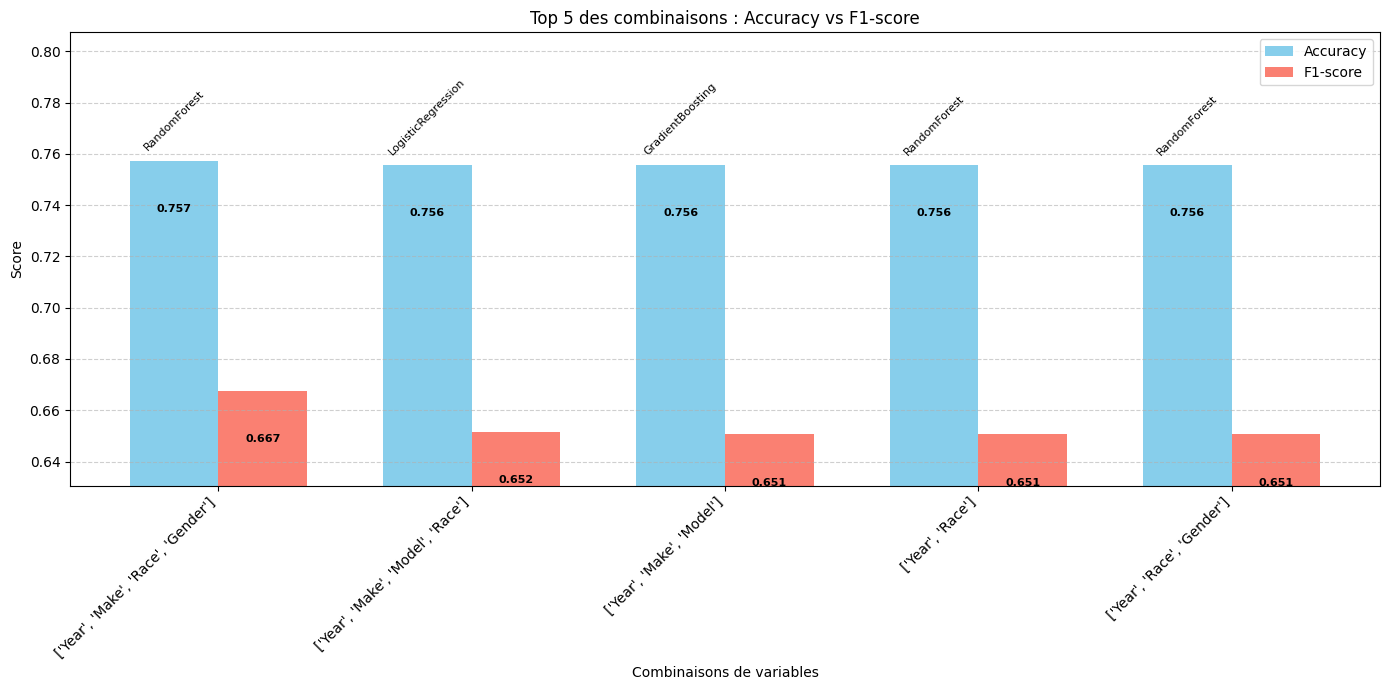

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# MEILLEUR MODELE PAR COMBINAISON
# -----------------------------
best_per_combination = df_results.loc[
    df_results.groupby("features")["accuracy"].idxmax()
].copy()

# -----------------------------
# TOP 5
# -----------------------------
top5 = best_per_combination.sort_values("accuracy", ascending=False).head(5)

top5["label"] = top5["features"].astype(str)

# -----------------------------
# POSITION DES BARRES
# -----------------------------
x = np.arange(len(top5))
width = 0.35

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(14,7))

bars1 = plt.bar(x - width/2, top5["accuracy"], width, label="Accuracy", color="skyblue")
bars2 = plt.bar(x + width/2, top5["f1"], width, label="F1-score", color="salmon")

# -----------------------------
# LABELS SUR LES BARRES
# -----------------------------
for bar, model in zip(bars1, top5["model"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        model,
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45
    )

# Valeurs sur les barres
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height - 0.02, f"{height:.3f}",
             ha='center', fontsize=8, fontweight="bold")

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height - 0.02, f"{height:.3f}",
             ha='center', fontsize=8, fontweight="bold")

# -----------------------------
# AXES
# -----------------------------
plt.xticks(x, top5["label"], rotation=45, ha="right")

min_val = min(top5["accuracy"].min(), top5["f1"].min())
max_val = max(top5["accuracy"].max(), top5["f1"].max())

plt.ylim(min_val - 0.02, max_val + 0.05)

# -----------------------------
# STYLE
# -----------------------------
plt.xlabel("Combinaisons de variables")
plt.ylabel("Score")
plt.title("Top 5 des combinaisons : Accuracy vs F1-score")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [36]:
# -----------------------------
# SAUVEGARDE
# -----------------------------
joblib.dump({
    "model": best_model,
    "features": best_features,
    "label_encoder": le
}, "best_model.pkl")

print("\n💾 Modèle sauvegardé dans best_model.pkl")

# -----------------------------
# REUTILISATION DU MODELE
# -----------------------------
data = joblib.load("best_model.pkl")

best_model = data["model"]
best_features = data["features"]
le = data["label_encoder"]

X_test_best = test[best_features]

predictions = best_model.predict(X_test_best)

# 🔁 retour aux labels d'origine
predictions = le.inverse_transform(predictions)

print("\n🔮 Prédictions prêtes !")


💾 Modèle sauvegardé dans best_model.pkl

🔮 Prédictions prêtes !


In [37]:
y_pred = pipe.predict(X_test)

0    0.974235
1    0.025765
Name: proportion, dtype: float64


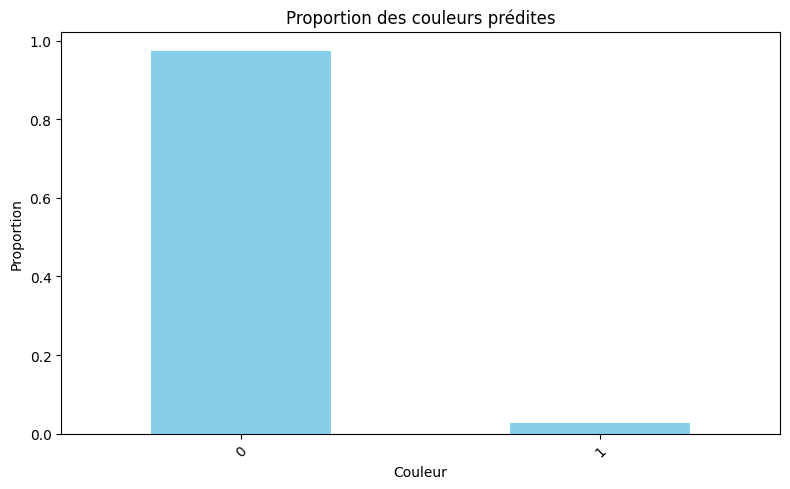

In [38]:
counts = pd.Series(y_pred).value_counts(normalize=True)
print(counts)

# Graphique
plt.figure(figsize=(8,5))
counts.plot(kind='bar', color='skyblue')

plt.title("Proportion des couleurs prédites")
plt.xlabel("Couleur")
plt.ylabel("Proportion")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Vetement 

In [39]:
choix_h = choix[choix['Gender'] == 'M']
vetement_h = vetements[vetements['gender'] == 'Male']

In [40]:
dist_voiture = choix_h['Color'].value_counts(normalize=True)
dist_vetement = vetement_h['color'].value_counts(normalize=True)

Couleurs communes : Index(['black', 'white', 'red', 'green', 'brown', 'beige', 'orange', 'yellow'], dtype='str')


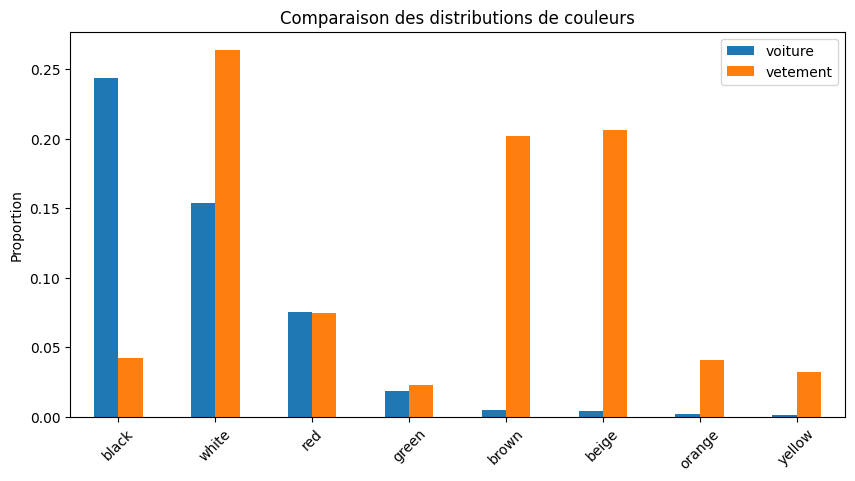

In [41]:
# distributions
dist_voiture = choix['Color'].str.lower().value_counts(normalize=True)
dist_vetement = vetements['color'].str.lower().value_counts(normalize=True)

# couleurs communes
common = dist_voiture.index.intersection(dist_vetement.index)

print("Couleurs communes :", common)

df = pd.DataFrame({
    'voiture': dist_voiture.loc[common],
    'vetement': dist_vetement.loc[common]
})

df.plot(kind='bar', figsize=(10,5))
plt.title("Comparaison des distributions de couleurs")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()